In [1]:
from __future__ import print_function
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

# Persamaan Hiperbolik - Bagian II

## Konsep Dasar Metode Karakteristik (Basic Concept of the Characteristic Method)
Untuk persamaan $  u_t + a u_x = 0  $ ($  a > 0  $), informasi merambat ke arah kanan sepanjang garis karakteristik dengan kecepatan $  a  $.

Artinya: nilai solusi di titik $  (x, t + \Delta t)  $ ditentukan sepenuhnya oleh nilai solusi di titik mundur sepanjang karakteristik:
$$x_p = x - a \Delta t$$
Jadi:
$$U(x, t + \Delta t) = U(x - a \Delta t, t)$$

Ini sempurna secara teori. Namun masalah muncul ketika kita berada di grid diskrit (titik-titik $  x_j = j \Delta x  $, $  t_n = n \Delta t  $).

## Masalah di Grid Diskrit (Problems in the Discrete Grid)
Kita hanya mengetahui nilai numerik $  U_j^n  $ di titik-titik grid saja.

Jarang sekali garis karakteristik dari $  (x_j, t_{n+1})  $ tepat mengenai salah satu titik grid di waktu $  t_n  $. Hanya ketika CFL number $  \nu = \frac{a \Delta t}{\Delta x} = 1  $ garis karakteristik akan tepat mengenai titik grid ($  x_j - a\Delta t = x_{j-1}  $).

Jika $  \nu < 1  $ (yang biasanya kita inginkan untuk stabilitas), titik asal karakteristik $  x_p = x_j - a\Delta t  $ berada di antara dua titik grid: antara $  x_{j-1}  $ dan $  x_j  $.
Karena itu, kita harus mengaproksimasi nilai $  U(x_p, t_n)  $ dengan interpolasi menggunakan nilai yang sudah diketahui di grid.

1. Interpolasi Linear → Metode Upwind Orde Satu

    Jika kita menggunakan interpolasi linear antara $  U_{j-1}^n  $ dan $  U_j^n  $ untuk memperkirakan nilai di $  x_p  $, maka setelah perhitungan aljabar yang cukup panjang (seperti yang sudah ditunjukkan di teks), kita akan memperoleh skema:
    $$U_j^{n+1} = U_j^n - \frac{a \Delta t}{\Delta x} (U_j^n - U_{j-1}^n)$$
    Ini persis skema Upwind (First-Order Upwind) yang sangat terkenal.

    Karena skema ini mengambil informasi dari arah datang angin (upwind), yaitu dari kiri ($  U_{j-1}^n  $), sesuai arah aliran ($  a > 0  $).
    Skema ini stabil jika $0 < \nu \leq 1$ (kondisi CFL).

2. Interpolasi Kuadratik → Metode Beam-Warming

    Jika kita naikkan tingkat interpolasi menjadi kuadratik (menggunakan tiga titik: $  U_{j-2}^n  $, $  U_{j-1}^n  $, $  U_j^n  $), maka kita akan mendapatkan skema yang lebih akurat (orde dua):

    $U_j^{n+1} = U_j^n - \frac{a \Delta t}{2 \Delta x} (3 U_j^n - 4 U_{j-1}^n + U_{j-2}^n) + \frac{a^2 \Delta t^2}{2 \Delta x^2} (U_j^n - 2 U_{j-1}^n + U_{j-2}^n)$

    Ini adalah skema Beam-Warming (juga dikenal sebagai upwind orde dua dengan koreksi dispersi).

    Skema ini memiliki akurasi yang lebih tinggi daripada upwind orde satu, tetapi masih bersifat upwind-biased (lebih banyak mengambil informasi dari kiri).

## Kondisi Courant-Friedrichs-Lewy (CFL)
CFL Condition adalah salah satu konsep paling penting dan fundamental dalam metode numerik untuk menyelesaikan Persamaan Diferensial Parsial (PDE), khususnya PDE tipe hiperbolik seperti persamaan adveksi (transport): $$u_t + a u_x = 0$$

Informasi dalam solusi PDE merambat dengan kecepatan tertentu (dalam kasus ini kecepatan $  a  $). Skema numerik harus mengambil informasi dari wilayah yang cukup luas agar tidak “ketinggalan” informasi yang seharusnya memengaruhi titik tersebut.

## Hubungan dengan Analisis Karakteristik (Relationship with Characteristic Analysis)
Nilai solusi di titik $  (x_j, t_{n+1})  $ ditentukan oleh nilai di titik mundur sepanjang garis karakteristik:
$$x_p = x_j - a \Delta t$$
Agar aproksimasi ini masuk akal di grid diskrit, titik $  x_p  $ harus berada di dalam interval $  [x_{j-1}, x_j]  $ (untuk $  a > 0  $). 

Jika titik $  x_p  $ berada di luar interval tersebut (terlalu jauh ke kiri atau bahkan ke kanan), maka skema numerik akan “melewatkan” informasi penting atau mengambil informasi dari arah yang salah.

Kondisi agar $  x_p  $ tetap berada di antara $  x_{j-1}  $ dan $  x_j  $ adalah:
$$x_{j-1} \leq x_j - a \Delta t \leq x_j$$
Yang setelah disederhanakan menjadi:
$$0 \leq \frac{a \Delta t}{\Delta x} \leq 1$$
Karena $  a  $ bisa bernilai negatif (aliran ke kiri), maka bentuk umumnya adalah:
$$\nu = \left| \frac{a \Delta t}{\Delta x} \right| \leq 1$$
Di sinilah Courant number ($  \nu  $) muncul.


## Domain Ketergantungan (Dependency Domain)
Domain of Dependence dari suatu titik $  (X, T)  $ adalah himpunan semua titik awal (pada waktu $  t=0  $ atau waktu sebelumnya) yang dapat memengaruhi nilai solusi $  u(X, T)  $.

Konsep ini sangat penting karena menjadi dasar CFL Condition yang lebih umum. CFL menyatakan bahwa untuk skema numerik agar konvergen, domain ketergantungan numerik (titik-titik grid yang digunakan skema) harus mencakup domain ketergantungan fisik (dari PDE yang sebenarnya).

* Domain of Dependence untuk Persamaan Adveksi (Hyperbolic PDE)

    Untuk persamaan adveksi sederhana:
    $$u_t + a u_x = 0 \quad (a > 0)$$
    Solusi eksaknya sangat jelas:
    $$u(X, T) = u_0(X - a T)$$
    Artinya, nilai di titik $  (X, T)  $ hanya ditentukan oleh satu titik tunggal pada kondisi awal, yaitu $  X - a T  $. Oleh karena itu:
    $$\mathcal{D}(X,T) = \{ X - a T \}$$

* Domain of Dependence untuk Persamaan Panas (Heat Equation) – Parabolic PDE
    Sekarang bandingkan dengan persamaan panas (diffusion equation):
    $$u_t = \beta u_{xx} \quad (\beta > 0)$$
    Domain of dependence-nya sangat berbeda:
    $$\mathcal{D}(X, T) = (-\infty, \infty)$$
    semua titik di seluruh garis riil pada waktu awal dapat memengaruhi nilai di $  (X, T)  $, meskipun pengaruhnya semakin kecil semakin jauh.

## Domain Ketergantungan Numerik (Domain of Numerical Dependence)
Setiap metode numerik (skema beda hingga) memiliki domain ketergantungan numerik sendiri, yang ditentukan oleh stencil yang digunakan.

Stencil adalah pola titik-titik grid yang dipakai untuk menghitung nilai baru $  U_j^{n+1}  $ dari nilai-nilai pada waktu sebelumnya.

Untuk skema numerik agar konvergen ke solusi PDE yang benar ketika $  \Delta x  $ dan $  \Delta t  $ mengecil, numerical domain of dependence harus mencakup (atau setidaknya tidak lebih kecil dari) physical domain of dependence.

---
#### **Contoh: Metode Lax-Friedrichs**

Skema Lax-Friedrichs untuk persamaan adveksi $  u_t + a u_x = 0  $ biasanya ditulis sebagai:
$$U_j^{n+1} = \frac{1}{2} (U_{j-1}^n + U_{j+1}^n) - \frac{a \Delta t}{2 \Delta x} (U_{j+1}^n - U_{j-1}^n)$$
Dari rumus ini terlihat jelas bahwa nilai $  U_j^{n+1}  $ bergantung pada tiga titik di waktu $  t_n  $:

$  U_{j-1}^n  $
$  U_j^n  $ (kadang tidak langsung, tapi dalam bentuk lain)
$  U_{j+1}^n  $

Jadi, numerical domain of dependence pada satu langkah waktu adalah interval $  [x_{j-1}, x_{j+1}]  $ (lebar 2$  \Delta x  $).

Ini berbeda dengan physical domain of dependence adveksi yang hanya satu titik ($  x_j - a \Delta t  $).


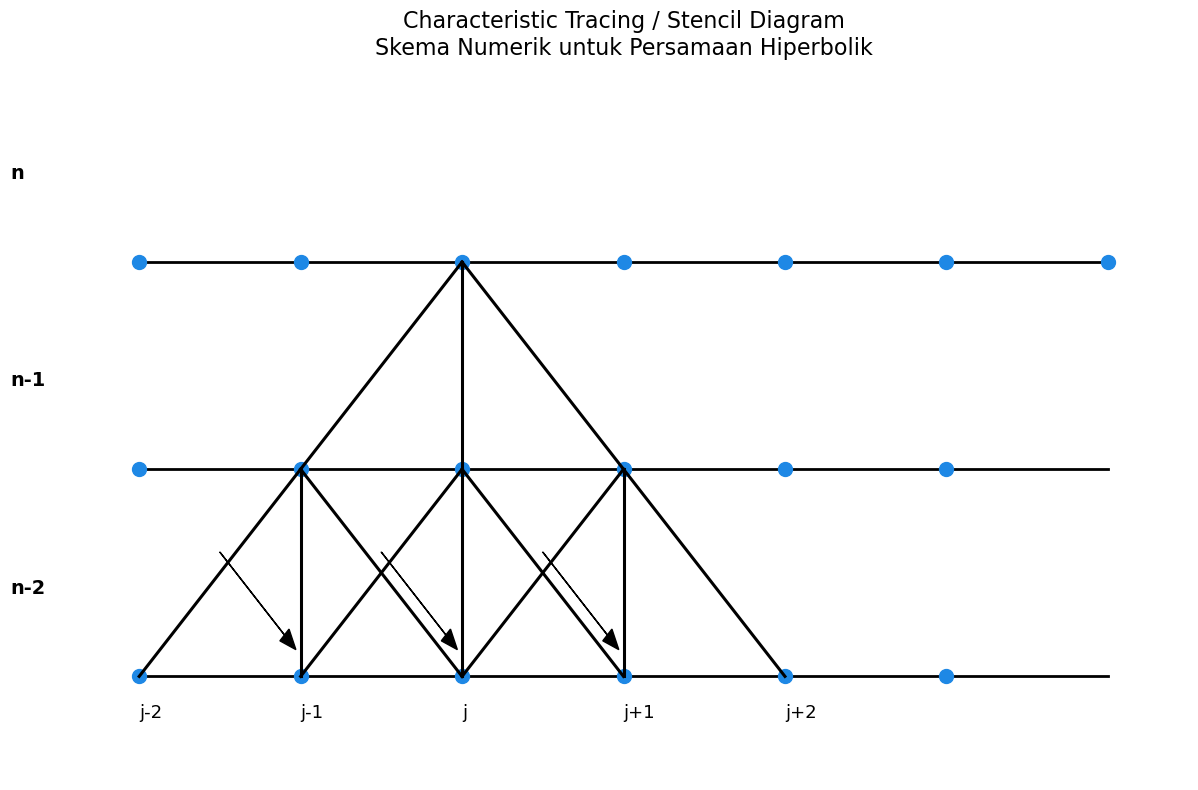

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ================== SETUP FIGURE DAN AXIS ==================
fig, ax = plt.subplots(figsize=(12, 8))           # Buat figure dengan ukuran yang proporsional

# ================== SETTING BATAS DAN LABEL ==================
ax.set_xlim(-2.5, 4.5)                            # Batas sumbu x untuk menampung j-2 sampai j+2
ax.set_ylim(-0.5, 2.8)                            # Batas sumbu y untuk level waktu n, n-1, n-2

# Sembunyikan sumbu numerik agar tampilan lebih bersih seperti diagram
ax.set_xticks([])                                 # Hilangkan tick angka di sumbu x
ax.set_yticks([])                                 # Hilangkan tick angka di sumbu y

# ================== LABEL LEVEL WAKTU (n, n-1, n-2) ==================
ax.text(-2.8, 2.4, 'n',     fontsize=14, fontweight='bold')      # Label waktu level n
ax.text(-2.8, 1.4, 'n-1',   fontsize=14, fontweight='bold')      # Label waktu level n-1
ax.text(-2.8, 0.4, 'n-2',   fontsize=14, fontweight='bold')      # Label waktu level n-2

# ================== LABEL POSISI GRID DI LEVEL BAWAH ==================
ax.text(-2.0, -0.2, 'j-2',  fontsize=13)         # Label posisi grid j-2
ax.text(-1.0, -0.2, 'j-1',  fontsize=13)         # Label posisi grid j-1
ax.text( 0.0, -0.2, 'j',    fontsize=13)         # Label posisi grid j
ax.text( 1.0, -0.2, 'j+1',  fontsize=13)         # Label posisi grid j+1
ax.text( 2.0, -0.2, 'j+2',  fontsize=13)         # Label posisi grid j+2

# ================== MENGGAMBAR GARIS HORIZONTAL (LEVEL WAKTU) ==================
ax.plot([-2, 4], [2, 2], 'k-', linewidth=2)      # Garis horizontal level waktu n
ax.plot([-2, 4], [1, 1], 'k-', linewidth=2)      # Garis horizontal level waktu n-1
ax.plot([-2, 4], [0, 0], 'k-', linewidth=2)      # Garis horizontal level waktu n-2

# ================== MENGGAMBAR TITIK-TITIK GRID (blue dots) ==================
# Level n (atas)
for i in range(-2, 5):
    ax.plot(i, 2, 'o', color='#1e88e5', markersize=10)   # Titik biru di level n

# Level n-1 (tengah)
for i in range(-2, 4):
    ax.plot(i, 1, 'o', color='#1e88e5', markersize=10)   # Titik biru di level n-1

# Level n-2 (bawah)
for i in range(-2, 4):
    ax.plot(i, 0, 'o', color='#1e88e5', markersize=10)   # Titik biru di level n-2

# ================== MENGGAMBAR GARIS KARAKTERISTIK / STENCIL ==================
# Garis dari level n ke level n-1
ax.plot([0, -1], [2, 1], 'k-', linewidth=2.2)    # Dari j   ke j-1  (kiri)
ax.plot([0,  0], [2, 1], 'k-', linewidth=2.2)    # Dari j   ke j    (vertikal)
ax.plot([0,  1], [2, 1], 'k-', linewidth=2.2)    # Dari j   ke j+1  (kanan)

# Garis dari level n-1 ke level n-2
ax.plot([-1, -2], [1, 0], 'k-', linewidth=2.2)   # Dari j-1 ke j-2
ax.plot([-1, -1], [1, 0], 'k-', linewidth=2.2)   # Dari j-1 ke j-1
ax.plot([-1,  0], [1, 0], 'k-', linewidth=2.2)   # Dari j-1 ke j

ax.plot([0, -1], [1, 0], 'k-', linewidth=2.2)    # Dari j   ke j-1
ax.plot([0,  0], [1, 0], 'k-', linewidth=2.2)    # Dari j   ke j
ax.plot([0,  1], [1, 0], 'k-', linewidth=2.2)    # Dari j   ke j+1

ax.plot([1,  0], [1, 0], 'k-', linewidth=2.2)    # Dari j+1 ke j
ax.plot([1,  1], [1, 0], 'k-', linewidth=2.2)    # Dari j+1 ke j+1
ax.plot([1,  2], [1, 0], 'k-', linewidth=2.2)    # Dari j+1 ke j+2

# Tambahkan panah untuk menunjukkan arah informasi (characteristic tracing)
ax.arrow(-1.5, 0.6, 0.4, -0.4, head_width=0.08, head_length=0.1, fc='black', ec='black')  # Panah ke bawah kiri
ax.arrow(-0.5, 0.6, 0.4, -0.4, head_width=0.08, head_length=0.1, fc='black', ec='black')  # Panah ke bawah
ax.arrow( 0.5, 0.6, 0.4, -0.4, head_width=0.08, head_length=0.1, fc='black', ec='black')  # Panah ke bawah kanan

# ================== TAMBAHAN STYLING ==================
ax.set_title('Characteristic Tracing / Stencil Diagram\n'
             'Skema Numerik untuk Persamaan Hiperbolik', 
             fontsize=16, pad=30)

# Hilangkan garis sumbu agar tampilan lebih bersih
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()                                # Rapihkan layout
plt.show()                                        # Tampilkan diagram

Secara lebih rinci, jika kita mempertahankan rasio tetap $$  \Delta t / \Delta x = r  $$ saat memperhalus grid, maka numerical cone of dependence untuk titik $  (X, T)  $ akan membentuk interval $$  [X - T/r, X + T/r]  $$. Agar solusi numerik $  U(X,T)  $ dapat konvergen ke solusi eksak $$  u(X,T) = u_0(X - a T)  $$, titik ketergantungan fisik $  X - a T  $ harus berada di dalam interval numerik tersebut. Kondisi ini menghasilkan ketidaksamaan $$  X - T/r \leq X - a T \leq X + T/r  $$, yang pada akhirnya menyederhanakan menjadi $$  |a| \leq 1/r  $$, atau dengan kata lain $$  |\frac{a \Delta t}{\Delta x}| \leq 1  $$. Inilah yang kembali memberikan kita syarat CFL yang familiar.

Dapat dirumuskan pernyataan umum CFL condition sebagai berikut: suatu metode numerik hanya akan konvergen jika, saat $  \Delta t \to 0  $ dan $  \Delta x \to 0  $, domain ketergantungan numeriknya mengandung domain ketergantungan yang ditentukan oleh PDE asli. CFL bukan sekadar batas stabilitas praktis, melainkan syarat perlu (necessary condition) yang muncul secara alami dari perbandingan antara kerucut ketergantungan numerik dan fisik, sehingga metode numerik dapat “melihat” semua informasi yang seharusnya memengaruhi solusi di suatu titik.

### Contoh: Metode Upwind (Upwind Methods)
Skema upwind memiliki numerical domain of dependence yang hanya melibatkan stencil 2 titik (dua titik grid), dan arah stencil ini harus mengikuti tanda dari kecepatan $  a  $.
Jika kita memilih arah yang salah (wrong direction), maka saat $  \Delta t  $ dan $  \Delta x \to 0  $, titik fisik $  X - a T  $ (domain of dependence sebenarnya) tidak akan pernah berada di dalam cone of dependence numerik. Akibatnya, skema tidak dapat konvergen ke solusi yang benar, meskipun CFL number secara formal dipenuhi.

### Contoh: Persamaan Panas
Domain of dependence untuk persamaan panas (heat equation):
$$u_t = \beta u_{xx} \quad (\beta > 0)$$
adalah seluruh ruang:
$$\mathcal{D}(X, T) = (-\infty, +\infty)$$
Artinya, secara teori, setiap titik di seluruh garis ruang pada waktu sebelumnya dapat memengaruhi nilai solusi di titik $  (X, T)  $. Ini disebabkan oleh infinite propagation speed — efek panas menyebar secara instan ke segala arah, meskipun pengaruhnya semakin kecil semakin jauh.

Karena domain of dependence-nya tak terbatas, persyaratan CFL untuk heat equation jauh lebih ketat dibandingkan persamaan adveksi (hiperbolik).

## Persamaan yang Dimodifikasi (Modified Equation) 
Modified Equation (kadang disebut equivalent differential equation atau modified PDE) adalah salah satu alat analisis yang sangat powerful untuk memahami perilaku sebuah metode numerik.

Ada sebuah PDE baru (yang sedikit berbeda dari PDE asli) yang solusinya persis sama dengan nilai numerik $  U_j^n  $ yang dihasilkan skema. PDE baru inilah yang disebut modified equation.

### Contoh: Metode Upwind
$\nu \bigl( v - v(x-\Delta x,t) \bigr) = a \Delta t \left( v_x - \frac{\Delta x}{2} v_{xx} + \frac{(\Delta x)^2}{6} v_{xxx} + \cdots \right)$

Kita asumsikan ada fungsi halus $  v(x,t)  $ sehingga $  U_j^n = v(x_j, t_n)  $.

Maka skema menjadi:
$$v(x, t + \Delta t) = v(x,t) - \frac{a \Delta t}{\Delta x} \bigl( v(x,t) - v(x - \Delta x, t) \bigr)$$

---
1. Ekspansi Taylor Series

* Kembangkan $  v(x, t + \Delta t)  $ di sekitar $  (x, t)  $ hingga orde tinggi.

* Kembangkan $  v(x - \Delta x, t)  $ di sekitar $  (x, t)  $.

Setelah dimasukkan dan disederhanakan, diperoleh:$$v_t + a v_x = \frac{1}{2}(a \Delta x \, v_{xx} - \Delta t \, v_{tt}) + \frac{1}{6}(a \Delta x^2 \, v_{xxx} - \Delta t^2 \, v_{ttt}) + \cdots$$
Suku kiri ($  v_t + a v_x  $) adalah PDE asli (advection equation).

Suku kanan adalah modified terms — ini yang membedakan PDE yang benar-benar diselesaikan skema.

2. Menyederhanakan ke Orde Terendah (Leading Order)

Suku orde $  \mathcal{O}(\Delta x, \Delta t)  $:$$v_t + a v_x = \frac{1}{2}(a \Delta x \, v_{xx} - \Delta t \, v_{tt}) + \ higher\ order\ terms$$
Untuk menghilangkan turunan waktu orde dua ($  v_{tt}  $), dilakukan langkah cerdas:
* Diferensiasikan persamaan secara parsial terhadap $  t  $ dan $  x  $.

* Gunakan PDE asli ($  v_t \approx -a v_x  $) untuk mengganti $  v_{tt} \approx a^2 v_{xx}  $.

Hasil akhir setelah penyederhanaan:$$v_t + a v_x = \frac{a \Delta x}{2} \left(1 - \frac{a \Delta t}{\Delta x}\right) v_{xx} + \mathcal{O}(\Delta x^2, \Delta t^2)$$Ini adalah modified equation untuk skema upwind orde satu.

## Contoh: Lax-Wendroff
Dengan prosedur yang sama seperti pada upwind (mengganti $  U  $ dengan $  v(x,t)  $, melakukan ekspansi Taylor di ruang dan waktu, lalu mengumpulkan suku-suku), diperoleh modified equation hingga orde $  \mathcal{O}(\Delta x^2, \Delta t^2)  $:
$$v_t + a v_x = -\frac{1}{6} a \Delta x^2 \left(1 - \left(\frac{a \Delta t}{\Delta x}\right)^2 \right) v_{xxx} + \mathcal{O}(\Delta x^3, \Delta t^3)$$


#### Catatan - Dispersi
Dispersi adalah fenomena di mana komponen-komponen berbeda dari suatu solusi (berdasarkan panjang gelombang atau wave number $  \xi  $) merambat dengan kecepatan yang berbeda-beda.

##### **Contoh PDE Murni Dispersi: $  u_t = u_{xxx}  $**
Pertimbangkan persamaan Cauchy:
$$u_t = u_{xxx}$$
Lakukan Fourier transform terhadap ruang $  x  $:
$$\hat{u}_t(\xi, t) = -i \xi^3 \hat{u}(\xi, t)$$
Solusinya:
$$\hat{u}(\xi, t) = \hat{u}_0(\xi) \, e^{-i \xi^3 t}$$
Inverse Fourier transform memberikan:
$$u(x,t) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{\infty} \hat{u}_0(\xi) \, e^{i \xi (x - \xi^2 t)} \, d\xi$$

#### **Perbandingan dengan Persamaan Adveksi Murni**

Untuk persamaan adveksi $  u_t + a u_x = 0  $:
$$u(x,t) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{\infty} \hat{u}_0(\xi) \, e^{i \xi (x - a t)} \, d\xi$$
Semua wave number $  \xi  $ bergerak dengan kecepatan yang sama ($  a  $). Bentuk gelombang dipertahankan sempurna (hanya bergeser), tidak ada penyebaran.

#### **Persamaan Adveksi + Dispersi Umum**

Persamaan yang lebih umum:
$$u_t + a u_x + b u_{xxx} = 0$$
Solusinya dalam domain Fourier:
$$u(x,t) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{\infty} \hat{u}_0(\xi) \, e^{i \xi \bigl(x - (a - b \xi^2) t\bigr)} \, d\xi$$
Kecepatan fase efektif menjadi $  a - b \xi^2  $. Tanda dan besarnya $  b  $ menentukan apakah dispersi mendominasi atau tidak.

#### **Dispersi pada Persamaan yang Dimodifikasi Lax-Wendroff**

Dari modified equation Lax-Wendroff sebelumnya:
$$v_t + a v_x = -\frac{1}{6} a \Delta x^2 \left(1 - \nu^2 \right) v_{xxx} + \ higher\ order\ terms$$
Ini setara dengan $  b = \frac{1}{6} a \Delta x^2 (1 - \nu^2)  $ (dengan tanda negatif).

Group velocity (kecepatan paket gelombang / propagasi energi) dihitung sebagai:
$$c_g = a - \frac{1}{2} a \Delta x^2 \left(1 - \nu^2 \right) \xi^2$$

#### **Orde Lebih Tinggi dalam Persamaan yang Dimodifikasi**

Jika kita pertahankan suku hingga orde empat:
$$v_t + a v_x + \frac{1}{6} a \Delta x^2 (1 - \nu^2) v_{xxx} + \epsilon v_{xxxx} = 0$$
dengan $  \epsilon = \mathcal{O}(\Delta x^3 + \Delta t^3)  $.

Suku $  v_{xxxx}  $ disebut hyper-diffusion (difusi orde empat). Suku ini bersifat dissipative (melemahkan amplitudo gelombang pendek) dan biasanya membantu meredam osilasi frekuensi tinggi yang tidak diinginkan.

#### **Keterbatasan Persamaan yang Dimodifikasi dan Analisis von Neumann**

Modified equation memberikan estimasi yang baik hanya ketika wave number $  \xi  $ relatif kecil dibandingkan resolusi grid, yaitu $  \xi \Delta x \ll 1  $ (gelombang yang cukup halus terhadap grid).

Jika solusi mengandung gelombang sangat osilatori ($  \xi \Delta x \gg 1  $, mendekati frekuensi Nyquist), maka suku orde tinggi menjadi penting, dan modified equation kurang akurat.

Untuk kasus ini, cara yang lebih tepat adalah menggunakan ansatz gelombang (plane wave assumption):
$$u(x,t) = e^{i (\xi x_j - \omega(\xi) t_n)}$$
Ini sangat terkait dengan analisis von Neumann (stabilitas Fourier), di mana amplification factor $  g(\xi)  $ diganti dengan $  e^{-i \omega(\xi) \Delta t}  $. Analisis ini memberikan informasi akurat tentang phase error dan group velocity numerik bahkan untuk gelombang pendek.

### Contoh: Beam-Warning

Modified equation untuk Beam-Warming (hingga orde $  \mathcal{O}(\Delta x^2)  $) adalah:
$$v_t + a v_x = \frac{1}{6} a \Delta x^2 \left( 2 - 3\nu + \nu^2 \right) v_{xxx} + \ higher\ order\ terms$$
di mana $  \nu = \frac{a \Delta t}{\Delta x}  $ (Courant number).

* Sama seperti Lax-Wendroff, error dominan pada Beam-Warming adalah dispersive (suku $  v_{xxx}  $).

    Tidak ada suku difusi orde dua ($  v_{xx}  $) pada leading term. Ini berarti Beam-Warming jauh lebih sedikit difusif dibandingkan upwind orde satu.

* Koefisien di depan $  v_{xxx}  $ adalah:$$\frac{a \Delta x^2}{6}  \left(2 - 3\nu + \nu^2 \right)$$Perhatikan bahwa polinomial $2 - 3\nu + \nu^2 = (\nu - 1)(\nu - 2)$ memiliki tanda yang berbeda dengan Lax-Wendroff.

    Untuk rentang stabilitas Beam-Warming ($0 < \nu \leq 1$), koefisien ini positif. (Pada Lax-Wendroff koefisiennya negatif.)
* Dari analisis dispersi (seperti yang dibahas di bagian "An Aside - Dispersion"), group velocity untuk persamaan dengan suku $  b u_{xxx}  $ adalah:$$c_g = a - 3b \xi^2$$Karena koefisien $  b  $ pada Beam-Warming positif, maka:
$$c_g = a - 3 \times (\text{koefisien positif}) \xi^2 < a ? \quad \text{Wait — actually the sign works out to } c_g > a$$



### Contoh: Leapfrog
Leapfrog adalah skema eksplisit orde dua yang sangat populer untuk persamaan hiperbolik.

#### **Persamaan yang Dimodifikasi untuk Leapfrog**
Setelah dilakukan ekspansi Taylor dan pengumpulan suku-suku, diperoleh:
$$v_t + a v_x + \frac{1}{6} a \Delta x^2 \left(1 - \nu^2 \right) v_{xxx} = \epsilon_1 v_{xxxxx} + \epsilon_2 v_{xxxxxxx} + \cdots$$
di mana $  \nu = \frac{a \Delta t}{\Delta x}  $.

#### **Hubungan Dispersi yang Tepat (Analisis Fourier)**

Dengan memasukkan ansatz gelombang (plane wave):
$$v(x_j, t_n) = e^{i(\xi x_j - \omega t_n)}$$
ke dalam skema Leapfrog, diperoleh hubungan dispersion relation yang exact untuk metode numerik:
$$\sin(\omega \Delta t) = \nu \sin(\xi \Delta x)$$
Dari sini dapat dihitung group velocity numerik:
$$c_g = \frac{d\omega}{d\xi} = \pm \frac{a \cos(\xi \Delta x)}{\sqrt{1 - \nu^2 \sin^2(\xi \Delta x)}}$$

## Sistem Persamaan Hiperbolik (Hyperbolic Equation System)
Sistem disebut hiperbolik jika matriks $  A  $ memenuhi dua syarat penting:

1. $ A  $ dapat didiagonalkan (diagonalizable), yaitu memiliki $ s$ buah eigenvector yang linier independen.

2. Semua eigenvalue $  \lambda_1, \lambda_2, \dots, \lambda_s  $ adalah real.

Kita bisa menulis:
$$A = R \Lambda R^{-1}$$
di mana:

$  R = [ \mathbf{r}_1 \ | \ \mathbf{r}_2 \ | \ \dots \ | \ \mathbf{r}_s ]  $ adalah matriks yang kolom-kolomnya adalah eigenvector (right eigenvectors),
$  \Lambda = \text{diag}(\lambda_1, \lambda_2, \dots, \lambda_s)  $ adalah matriks diagonal yang berisi eigenvalue (kecepatan karakteristik).

Langkah paling penting adalah transformasi ke variabel karakteristik:

$$\mathbf{w} = R^{-1} \mathbf{u}$$
Maka sistem asli berubah menjadi:
$$\mathbf{w}_t + \Lambda \mathbf{w}_x = 0$$
Sekarang sistem terdecouple sempurna menjadi s buah persamaan adveksi independen:
$$\frac{\partial w_p}{\partial t} + \lambda_p \frac{\partial w_p}{\partial x} = 0, \quad p = 1,2,\dots,s$$
Solusi eksak untuk setiap komponen adalah:
$$w_p(x,t) = w_p(x - \lambda_p t, 0)$$
Setelah mendapatkan solusi di ruang variabel karakteristik $  \mathbf{w}  $, kita transformasi balik:
$$\mathbf{u}(x,t) = R \mathbf{w}(x,t)$$
Atau dalam bentuk yang lebih eksplisit:
$$\mathbf{u}(x,t) = \sum_{p=1}^{s} w_p(x - \lambda_p t,\ 0) \, \mathbf{r}_p$$
Di mana $  \mathbf{r}_p  $ adalah eigenvector ke-$  p  $ (kolom ke-$  p  $ dari matriks $  R  $).


### Metode Numerik (Numerical Method)
Kita dapat memperluas hampir semua skema numerik yang sudah dibahas (Upwind, Lax-Wendroff, Beam-Warming, Leapfrog, dll.) dari kasus scalar ke kasus sistem ($  \mathbf{u}_t + A \mathbf{u}_x = 0  $). Namun, ada perbedaan penting tergantung pada jenis skema yang digunakan.

1. Skema Berbasis Centered (Centered Schemes)

    Skema-skema yang menggunakan selisih pusat (centered difference) dapat langsung digeneralisasi dengan mengganti kecepatan skalar $  a  $ menjadi matriks $  A  $.

    Contoh: Lax-Wendroff untuk sistem

    $$
    \mathbf{U}_j^{n+1} = \mathbf{U}_j^n 
    - \frac{\Delta t}{2 \Delta x} A (\mathbf{U}_{j+1}^n - \mathbf{U}_{j-1}^n) 
    + \frac{\Delta t^2}{2 \Delta x^2} A^2 (\mathbf{U}_{j+1}^n - 2 \mathbf{U}_j^n + \mathbf{U}_{j-1}^n)
    $$
    Skema ini tetap berlaku selama memenuhi syarat stabilitas.

2. Skema One-Sided / Upwind

    Skema yang biased ke satu arah (seperti Upwind orde 1 dan Beam-Warming) tidak bisa langsung diganti dari a ke A begitu saja, kecuali semua eigenvalue memiliki tanda yang sama (semua positif atau semua negatif). 

    Karena arah "upwind" bergantung pada tanda kecepatan. Dalam sistem, ada eigenvalue positif (gelombang ke kanan) dan negatif (gelombang ke kiri) secara bersamaan. Jika kita menggunakan stencil yang salah untuk salah satu gelombang, skema akan menjadi downwind untuk gelombang tersebut sehingga menjadi tidak stabil.

    Metode yang mengikuti prosedur ini secara umum disebut Godunov-type methods atau characteristic-based methods.

## Batas (Boundaries)
Persamaan hiperbolik:
$$u_t + a u_x = 0, \quad x \in \Omega = [0, 1], \quad t > 0$$
dengan kondisi awal:
$$u(x, 0) = u_0(x), \quad x \in [0,1]$$
dan kondisi batas yang belum ditentukan di $  x=0  $ dan $  x=1  $.

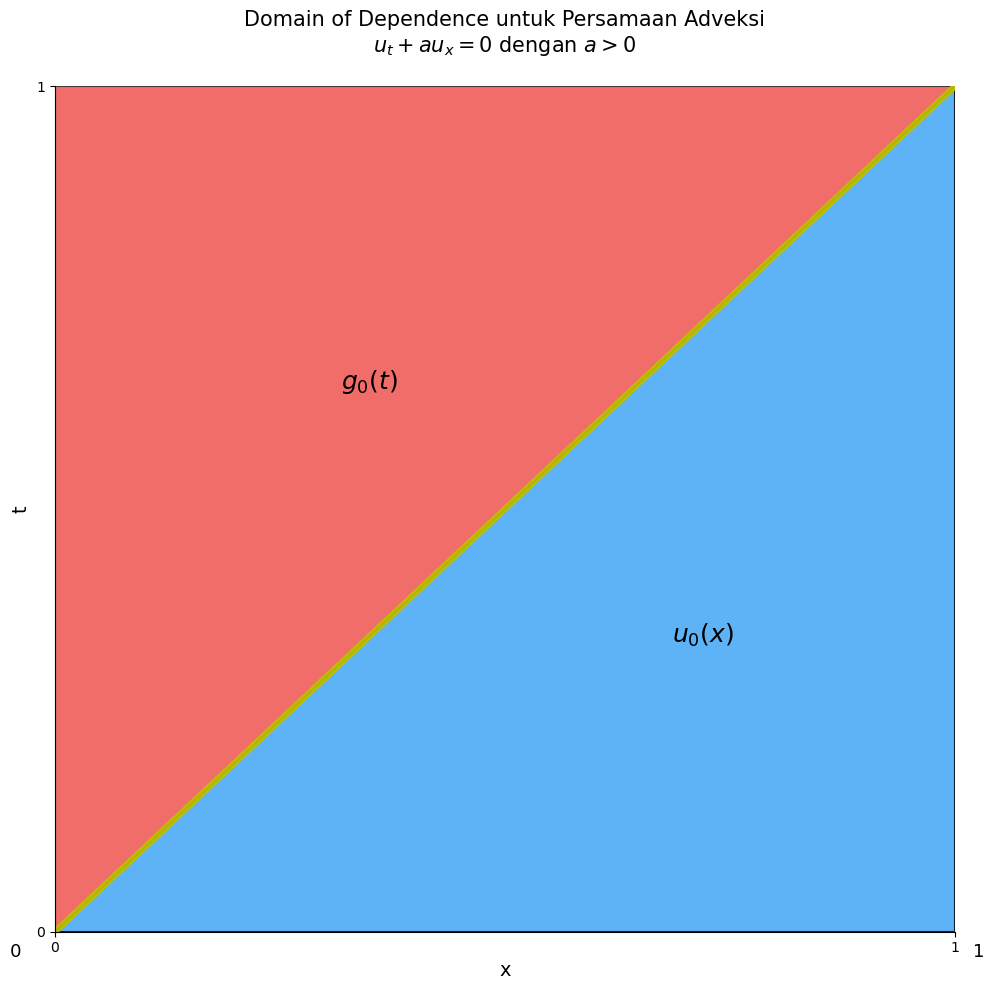

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# ================== MEMBUAT FIGURE DAN AXIS ==================
fig, ax = plt.subplots(figsize=(10, 10))          # Membuat figure dengan ukuran kotak yang proporsional (10x10)

# ================== SETTING BATAS DAN LABEL SUMBU ==================
ax.set_xlim(0, 1)                                 # Domain x dari 0 sampai 1
ax.set_ylim(0, 1)                                 # Domain t dari 0 sampai 1
ax.set_xlabel('x', fontsize=14)                   # Label sumbu x
ax.set_ylabel('t', fontsize=14)                   # Label sumbu t (vertikal)

# Judul diagram
ax.set_title('Domain of Dependence untuk Persamaan Adveksi\n'
             '$u_t + a u_x = 0$ dengan $a > 0$', 
             fontsize=15, pad=25)

# ================== MENGGAMBAR GARIS KARAKTERISTIK (garis kuning) ==================
ax.plot([0, 1], [0, 1], 'y-', linewidth=4.5, alpha=0.95)   # Garis diagonal utama dari (0,0) ke (1,1)

# ================== MENGISI DAERAH MERAH (Inflow Region) ==================
# Daerah merah: dipengaruhi oleh g0(t) di batas kiri
red_region = Polygon([[0,0], [0,1], [1,1]], closed=True, 
                     facecolor='#ef5350', alpha=0.85, edgecolor='black', linewidth=1.5)
ax.add_patch(red_region)

# ================== MENGISI DAERAH BIRU (Initial Condition Region) ==================
# Daerah biru: hanya dipengaruhi oleh kondisi awal u0(x)
blue_region = Polygon([[0,0], [1,0], [1,1]], closed=True, 
                      facecolor='#42a5f5', alpha=0.85, edgecolor='black', linewidth=1.5)
ax.add_patch(blue_region)

# ================== MENAMBAHKAN LABEL PADA SETIAP DAERAH ==================
# Label untuk daerah merah (g0(t))
ax.text(0.35, 0.65, '$g_0(t)$', fontsize=18, color='black', 
        fontweight='bold', ha='center', va='center')

# Label untuk daerah biru (u0(x))
ax.text(0.72, 0.35, '$u_0(x)$', fontsize=18, color='black', 
        fontweight='bold', ha='center', va='center')

# ================== LABEL PADA SUMBU ==================
ax.text(-0.05, -0.03, '0', fontsize=13)           # Label x = 0
ax.text(1.02, -0.03, '1', fontsize=13)            # Label x = 1

# ================== TAMBAHAN STYLING ==================
ax.grid(True, alpha=0.25)                         # Tambahkan grid tipis untuk referensi
ax.set_xticks([0, 1])                             # Hanya tampilkan angka 0 dan 1 di sumbu x
ax.set_yticks([0, 1])                             # Hanya tampilkan angka 0 dan 1 di sumbu t

# Hilangkan garis atas dan kanan agar lebih bersih
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()                                # Rapihkan layout otomatis
plt.show()                                        # Tampilkan diagram

Ketika kita memiliki sistem persamaan hiperbolik dengan eigenvalue yang memiliki tanda berlawanan (ada kecepatan positif dan negatif), maka:

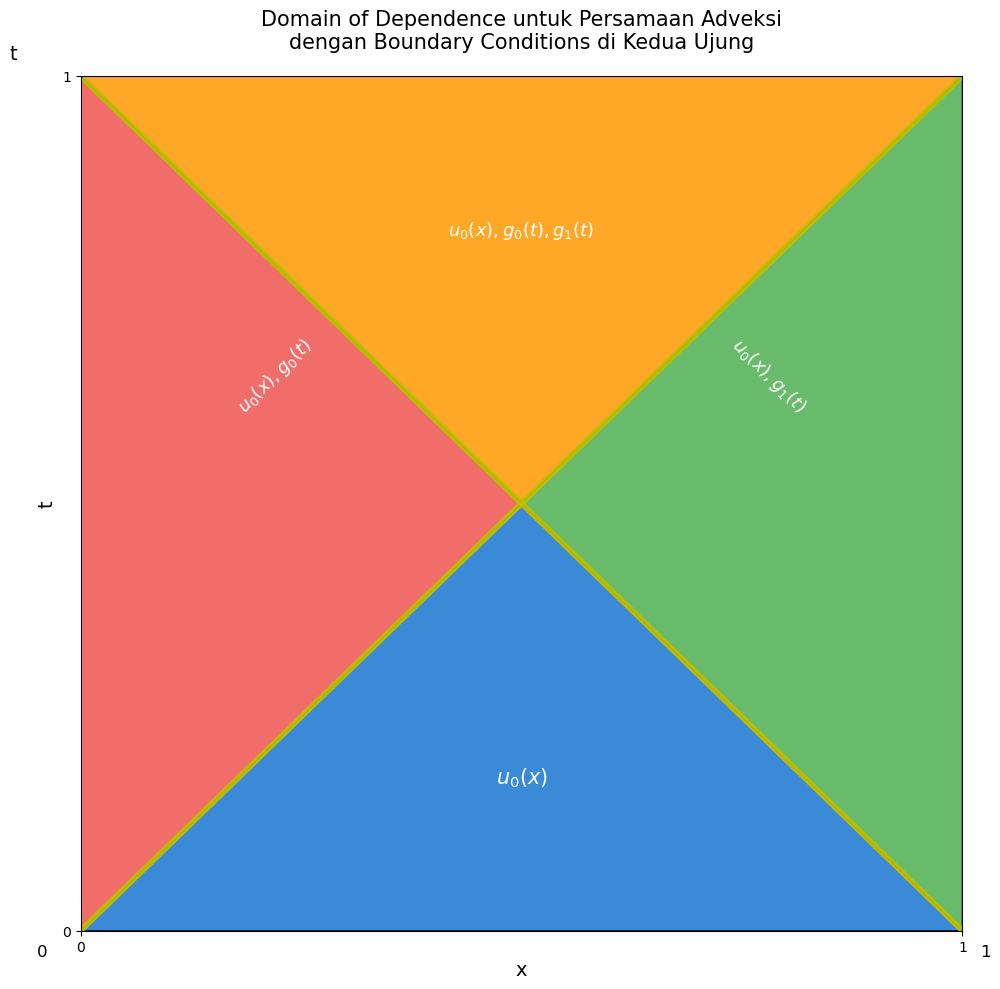

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# ================== MEMBUAT FIGURE DAN AXIS ==================
fig, ax = plt.subplots(figsize=(10, 10))          # Buat figure berukuran 10x10 inch agar proporsi kotak sempurna

# ================== BATAS DOMAIN ==================
ax.set_xlim(0, 1)                                 # Domain x dari 0 sampai 1
ax.set_ylim(0, 1)                                 # Domain t dari 0 sampai 1
ax.set_xlabel('x', fontsize=14)                   # Label sumbu x
ax.set_ylabel('t', fontsize=14)                   # Label sumbu t (vertikal)
ax.set_title('Domain of Dependence untuk Persamaan Adveksi\n'
             'dengan Boundary Conditions di Kedua Ujung', fontsize=15, pad=20)

# ================== MENGGAMBAR GARIS KARAKTERISTIK (garis kuning) ==================
ax.plot([0, 1], [0, 1], 'y-', linewidth=4, alpha=0.95)   # Garis diagonal utama (dari (0,0) ke (1,1))
ax.plot([0, 1], [1, 0], 'y-', linewidth=4, alpha=0.95)   # Garis diagonal kedua (dari (0,1) ke (1,0))

# ================== MENGISI 4 DAERAH DENGAN WARNA SESUAI GAMBAR ==================

# Daerah BIRU (bawah) → hanya dipengaruhi u₀(x)
blue_region = Polygon([[0,0], [1,0], [0.5,0.5]], closed=True, facecolor='#1976d2', alpha=0.85, edgecolor='black')
ax.add_patch(blue_region)

# Daerah MERAH (kiri) → dipengaruhi u₀(x) dan g₀(t)
red_region = Polygon([[0,0], [0,1], [0.5,0.5]], closed=True, facecolor='#ef5350', alpha=0.85, edgecolor='black')
ax.add_patch(red_region)

# Daerah HIJAU (kanan) → dipengaruhi u₀(x) dan g₁(t)
green_region = Polygon([[1,0], [1,1], [0.5,0.5]], closed=True, facecolor='#4caf50', alpha=0.85, edgecolor='black')
ax.add_patch(green_region)

# Daerah ORANYE (atas) → dipengaruhi u₀(x), g₀(t), dan g₁(t)
orange_region = Polygon([[0,1], [1,1], [0.5,0.5]], closed=True, facecolor='#ff9800', alpha=0.85, edgecolor='black')
ax.add_patch(orange_region)

# ================== MENAMBAHKAN LABEL PADA SETIAP DAERAH ==================
ax.text(0.5, 0.18, '$u_0(x)$', fontsize=15, color='white', fontweight='bold', ha='center', va='center')   # Label biru
ax.text(0.22, 0.65, '$u_0(x), g_0(t)$', fontsize=13, color='white', fontweight='bold', ha='center', va='center', rotation=45)   # Label merah
ax.text(0.78, 0.65, '$u_0(x), g_1(t)$', fontsize=13, color='white', fontweight='bold', ha='center', va='center', rotation=-45)  # Label hijau
ax.text(0.5, 0.82, '$u_0(x), g_0(t), g_1(t)$', fontsize=13, color='white', fontweight='bold', ha='center', va='center')   # Label oranye

# ================== MEMBERI LABEL PADA SUMBU ==================
ax.text(-0.05, -0.03, '0', fontsize=12)           # Label x = 0
ax.text(1.02, -0.03, '1', fontsize=12)            # Label x = 1
ax.text(-0.08, 1.02, 't', fontsize=14)            # Label t di atas

# ================== MENAMPILKAN GRID DAN MEMBERSIHKAN TAMPILAN ==================
ax.grid(True, alpha=0.2)                           # Tambah grid tipis
ax.set_xticks([0, 1])                              # Hanya tampilkan tick 0 dan 1 di x
ax.set_yticks([0, 1])                              # Hanya tampilkan tick 0 dan 1 di t

plt.tight_layout()                                 # Rapihkan layout agar tidak ada margin berlebih
plt.show()                                         # Tampilkan plot

### Upwind untuk Masalah Nilai Awal-Batas/IBVP (Initial-Boundary Value Problem)
Sebelumnya kita sering membahas skema numerik dengan asumsi kondisi periodik (periodic boundary conditions). Sekarang kita beralih ke masalah yang lebih realistis: Initial-Boundary Value Problem (IBVP), yaitu ada batas domain (boundary) yang harus ditangani.

Untuk persamaan adveksi $  u_t + a u_x = 0  $ dengan $  a > 0  $ pada interval $  [0,1]  $ misalnya, kita menggunakan grid:
$$\Delta x = \frac{1}{m+1}, \quad x_j = j \Delta x, \quad j = 0,1,2,\dots,m+1$$

* Titik $  x_0 = 0  $ adalah batas kiri (inflow boundary).
* Nilai $  U_0^n  $ diberikan oleh kondisi batas (boundary condition).
* Skema upwind orde satu hanya digunakan untuk titik-titik internal ($  j=1  $ sampai $  j=m  $).

Skema upwind untuk internal points:
$$U_j^{n+1} = U_j^n - \nu (U_j^n - U_{j-1}^n), \quad \nu = \frac{a \Delta t}{\Delta x}$$
Karena $  U_0^n  $ selalu diberikan dari boundary, skema ini sepenuhnya menentukan solusi di seluruh domain. Tidak ada kebebasan lagi.

#### **Metode Garis untuk Skema Upwind**
Kita diskretisasi hanya ruang terlebih dahulu, sehingga persamaan menjadi sistem ODE besar:
$$\frac{d\mathbf{U}}{dt} = A \mathbf{U} + \mathbf{g}(t)$$
di mana $  \mathbf{U}(t) = [U_1(t), U_2(t), \dots, U_m(t)]^T  $ adalah vektor solusi di titik internal.

Matriks $  A  $ untuk skema upwind ($  a > 0  $) adalah:
$$A = -\frac{a}{\Delta x} \begin{bmatrix}
1 & 0 & 0 & \cdots \\
-1 & 1 & 0 & \cdots \\
0 & -1 & 1 & \cdots \\
\vdots & \vdots & \ddots & \ddots \\
0 & 0 & \cdots & -1 & 1
\end{bmatrix}$$
dan vektor $  \mathbf{g}(t)  $ hanya memiliki elemen pertama yang non-zero:
$$\mathbf{g}(t) = \begin{bmatrix} 
\frac{a}{\Delta x} g_0(t) \\ 
0 \\ 
\vdots \\ 
0 
\end{bmatrix}$$
($  g_0(t)  $ berasal dari kondisi batas kiri $  U_0(t)  $).

Matriks ini sangat berbeda dengan matriks yang muncul pada kasus periodic:

* Eigenvalue-eigenvalue-nya tidak lagi murni imajiner.
* Eigenvalue tersebar di dalam lingkaran di bidang kompleks dengan:
    * Pusat di $  z = -a/\Delta x  $
    * Radius $  = a/\Delta x  $

Karena eigenvalue berada di setengah bidang kiri (real part negatif), ini memberi harapan stabilitas.

### Batas Aliran Keluar (Outflow Boundaries)
Dalam masalah Initial-Boundary Value Problem (IBVP) yang realistis, domain komputasi bersifat terbatas (misalnya interval $  [0, L]  $).
Untuk persamaan adveksi $  u_t + a u_x = 0  $ dengan $  a > 0  $:

* Inflow boundary (batas kiri, $  x=0  $): Harus diberi kondisi batas yang tepat ($  u(0,t) = g_0(t)  $), karena informasi masuk dari sini.
* Outflow boundary (batas kanan, $  x=L  $): Secara fisik tidak memerlukan kondisi batas, karena informasi mengalir keluar dari domain.

Namun, banyak skema numerik (terutama skema orde tinggi atau centered) memerlukan nilai di titik batas outflow karena stencil mereka melebar ke kanan.

#### Contoh: Leapfrog + Upwind di Outflow
Misalkan kita menggunakan:

* Leapfrog (centered, orde dua) di seluruh titik internal.
* Di outflow boundary (titik paling kanan), kita menggunakan skema upwind orde satu sebagai pengganti kondisi batas.

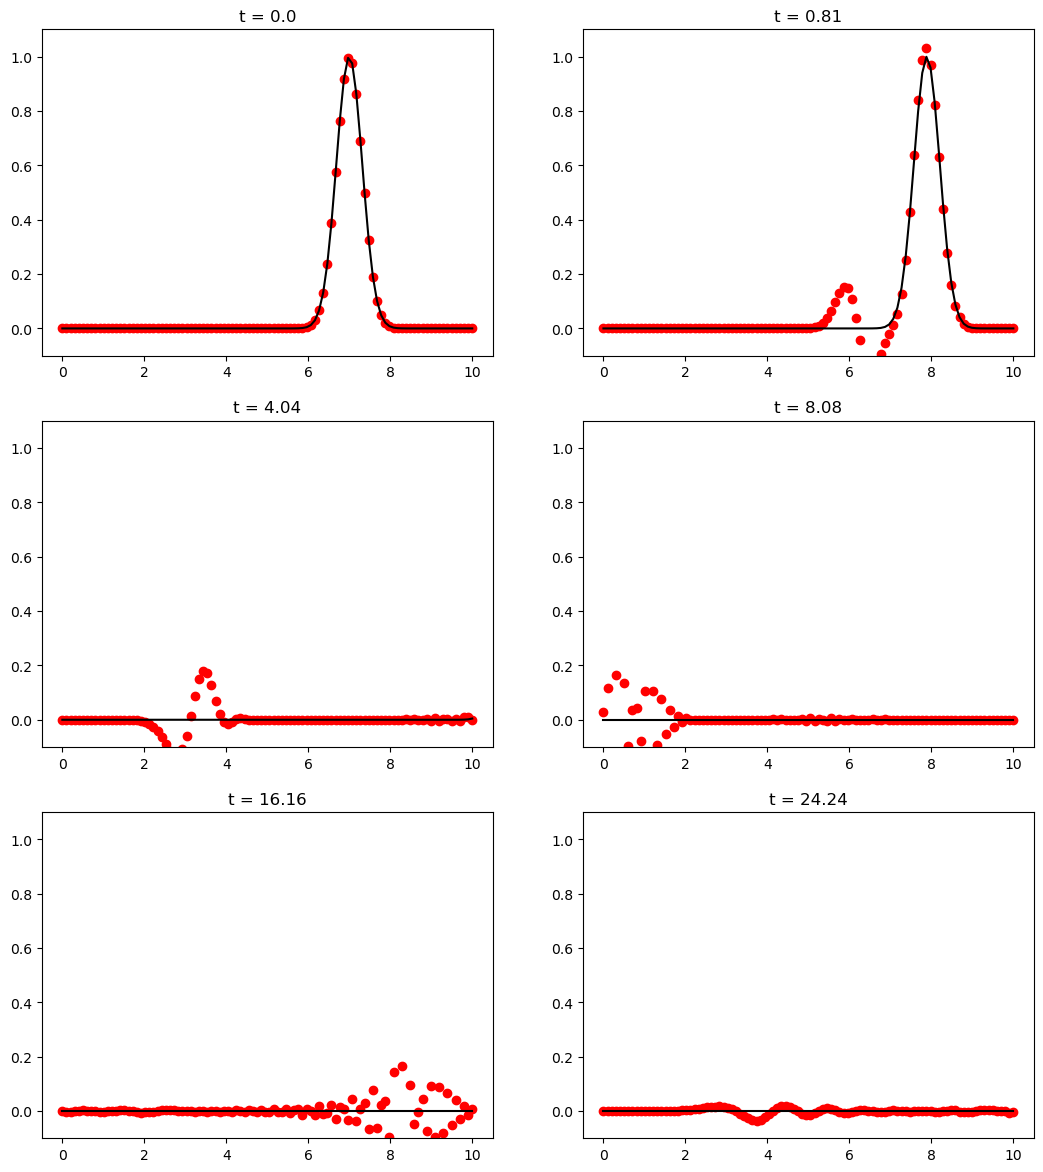

In [ ]:
# Implement Leapfrog for the PDE u_t + u_x = 0 on a finite domain [0, 10]

# Import library yang diperlukan (diasumsikan sudah di-import sebelumnya)
import numpy
import matplotlib.pyplot as plt

# ================================
# Definisi solusi eksak (untuk plotting dan inisialisasi)
# ================================
u_true = lambda x, t: numpy.exp(-5.0 * ((x - t - 7.0)**2))
# Penjelasan: Fungsi Gaussian yang bergerak ke kanan dengan kecepatan a=1.
# Pusat gelombang berada di x = t + 7.0. Fungsi ini digunakan sebagai solusi eksak
# untuk perbandingan dan inisialisasi awal.

# ================================
# Parameter grid dan waktu
# ================================
m = 100                                      # Jumlah titik grid (termasuk batas)
x = numpy.linspace(0, 10.0, m)               # Membuat grid ruang dari 0 sampai 10 dengan m titik
delta_x = 10.0 / (m - 1)                     # Lebar sel grid (Δx). Karena linspace, delta_x = 10/(m-1)

cfl = 0.8                                    # Courant number (ν = a Δt / Δx). Nilai 0.8 < 1 untuk stabilitas
delta_t = cfl * delta_x                      # Langkah waktu Δt dihitung dari CFL

# ================================
# Inisialisasi solusi numerik
# ================================
U = u_true(x, 0)                             # Solusi numerik pada t = 0 (diambil dari solusi eksak)
t = 0.0                                      # Waktu awal

# Jump start dengan true solution (karena Leapfrog butuh dua lapis waktu)
U_new = u_true(x, t + delta_t)               # Membuat lapis waktu t + Δt menggunakan solusi eksak
U_old = U_new.copy()                         # U_old menyimpan solusi pada t + Δt (untuk Leapfrog)

# ================================
# Persiapan plotting
# ================================
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)     # Membuat figure 2x lebih lebar
fig.set_figheight(fig.get_figheight() * 3)   # Membuat figure 3x lebih tinggi
axes = fig.add_subplot(3, 2, 1)              # Membuat subplot 3 baris × 2 kolom, posisi 1
axes.plot(x, U, 'ro')                        # Plot solusi numerik awal dengan titik merah
axes.plot(x, u_true(x, t), 'k')              # Plot solusi eksak dengan garis hitam
axes.set_ylim((-0.1, 1.1))                   # Batasi sumbu y agar tampilan lebih jelas
axes.set_title("t = 0.0")                    # Judul subplot pertama

# Mulai iterasi waktu
t += delta_t                                 # Majukan waktu ke Δt pertama

# ================================
# Loop utama simulasi
# ================================
for (n, t_final) in enumerate((10*delta_t, 50*delta_t, 100*delta_t, 200*delta_t, 300*delta_t)):
    # Loop ini akan membuat 5 subplot tambahan pada waktu tertentu
    
    while t < t_final:                       # Lakukan langkah waktu sampai mencapai t_final
        
        # ------------------- Batas kiri (Inflow boundary) -------------------
        U_new[0] = U_old[0] - delta_t / delta_x * (U[1] - u_true(0.0, t))
        # Penjelasan: 
        # Menggunakan Leapfrog untuk titik pertama (j=0).
        # Karena inflow, nilai U[0] diambil dari solusi eksak u_true(0,t) sebagai boundary condition.
        # Rumus: (U_new[0] - U_old[0])/(2Δt) + (U[1] - U[-1?])/(2Δx) ≈ 0, tapi disesuaikan dengan inflow.
        
        # ------------------- Titik internal (Leapfrog centered) -------------------
        U_new[1:-1] = U_old[1:-1] - delta_t / delta_x * (U[2:] - U[:-2])
        # Penjelasan:
        # Ini adalah inti skema Leapfrog untuk titik-titik internal (j=1 sampai j=m-2).
        # Rumus Leapfrog: 
        # (U_new[j] - U_old[j]) / (2Δt) + (U[j+1] - U[j-1]) / (2Δx) = 0
        # Disederhanakan menjadi bentuk di atas.
        
        # ------------------- Batas kanan (Outflow boundary) -------------------
        # Use upwind for outflow boundary
        U_new[-1] = U[-1] - delta_t / delta_x * (U[-1] - U[-2])
        # Penjelasan:
        # Menggunakan skema Upwind orde satu di titik terakhir (outflow).
        # Karena a > 0, informasi mengalir keluar, jadi menggunakan nilai dari kiri (U[-2]).
        # Ini adalah "artificial boundary condition" sederhana.
        
        # Update variabel untuk langkah berikutnya
        U_old = U.copy()                     # Simpan solusi saat ini sebagai U_old untuk langkah berikutnya
        U = U_new.copy()                     # Solusi baru menjadi solusi saat ini
        t += delta_t                         # Majukan waktu
        
    # ================================
    # Plot hasil pada waktu tertentu
    # ================================
    axes = fig.add_subplot(3, 2, n + 2)      # Pilih subplot berikutnya (posisi 2 sampai 6)
    axes.plot(x, U, 'ro')                    # Plot solusi numerik dengan titik merah
    axes.plot(x, u_true(x, t), 'k')          # Plot solusi eksak dengan garis hitam
    axes.set_ylim((-0.1, 1.1))               # Batasi sumbu y
    axes.set_title(f"t = {t_final:.2f}")     # Judul dengan waktu saat ini

plt.show()                                   # Tampilkan semua plot

Dalam simulasi numerik untuk persamaan hiperbolik (seperti adveksi, gelombang, atau persamaan Euler), outflow boundary (batas keluar) merupakan salah satu tantangan terbesar dan paling sulit ditangani.

## Alternatif
Bagian ini merupakan penutup dari seluruh pembahasan tentang metode numerik untuk persamaan diferensial parsial hiperbolik (khususnya adveksi dan sistem hiperbolik). 

Setelah membahas secara mendalam berbagai skema dasar seperti Upwind (orde 1), Lax-Wendroff Beam-Warming, Leapfrog, Godunov-type methods, Higher-order finite difference, Compact schemes, dan Spectral methods, masih banyak alternatif lain yang tidak sempat dibahas secara detail di materi ini.

### Diskretisasi Orde Tinggi (Higher Order Discretizations)
Bagian ini membahas cara meningkatkan akurasi diskretisasi ruang menjadi orde yang lebih tinggi (orde 3, 4, 5, dst.) untuk persamaan adveksi $  u_t + a u_x = 0  $.

Ada dua pendekatan utama yang dibahas:
1. Metode Garis + Beda Hingga Orde Tinggi (Wide Stencil)
    Kita mendiskretisasi ruang terlebih dahulu, sehingga Persamaan Diferensial Parsial berubah menjadi sistem Persamaan Diferensial Biasa (ODE):
    $$U_j'(t) = -a \, W_j(t)$$
    di mana $  W_j(t)  $ merupakan aproksimasi numerik dari turunan $  \frac{\partial u}{\partial x}  $ pada titik $  x_j  $.

    Selanjutnya, sistem ODE ini diintegrasikan terhadap waktu menggunakan metode orde tinggi, seperti Runge-Kutta atau multistep.

    **Contoh: aproksimasi orde tinggi (orde 4)**
    $$W_j(t) = \frac{4}{3} \left( \frac{U_{j+1} - U_{j-1}}{2 \Delta x} \right) - \frac{1}{3} \left( \frac{U_{j+2} - U_{j-2}}{4 \Delta x} \right)$$
    Rumus ini menggabungkan selisih tengah (centered difference) orde 2 dan orde 4, sehingga aproksimasi turunan pertama mencapai akurasi orde 4 ($  \mathcal{O}(\Delta x^4)  $).

2. Metode Diferensiasi Kompak (Compact Finite Difference)
    Alternatif untuk menghindari pelebaran stencil yang berlebihan adalah dengan menggunakan metode diferensiasi kompak (compact differencing methods atau compact finite difference).

    Pendekatan ini tidak menghitung nilai turunan $  W_j  $ secara langsung dari banyak titik $  U  $, melainkan menyusun sebuah sistem persamaan linear yang melibatkan nilai $  W_j  $ di titik-titik tetangga.

    **Contoh: skema kompak orde 4**
    $$\frac{1}{4} W_{j-1} + W_j + \frac{1}{4} W_{j+1} = \frac{3}{2} \left( \frac{U_{j+1} - U_{j-1}}{2 \Delta x} \right)$$

    Persamaan di atas harus diselesaikan secara simultan untuk semua titik $  j  $ (biasanya menghasilkan sistem tridiagonal yang efisien).

    Meskipun hanya menggunakan informasi dari $  U_{j-1}  $ dan $  U_{j+1}  $ (stencil yang sangat sempit), akurasi yang diperoleh tetap mencapai orde 4 ($  \mathcal{O}(\Delta x^4)  $).

### Metode Spektral
Spectral methods tidak menggunakan aproksimasi lokal seperti finite difference. Sebaliknya, mereka menggunakan pendekatan global.

Solusi $  u(x,t)  $ diaproksimasi menggunakan deret global yang terdiri dari fungsi-fungsi ortogonal (basis spektral), misalnya: Fungsi Fourier (paling umum untuk domain periodik), Polinomial Chebyshev, Polinomial Legendre, atau Wavelet (dalam beberapa kasus).

Setelah solusi direpresentasikan dalam basis spektral, turunan ruang ($  \partial u / \partial x  $) dapat dihitung secara eksak di ruang spektral (hanya dengan mengalikan koefisien dengan faktor tertentu, seperti $  ik  $ pada Fourier).

Hasil turunan kemudian ditransformasi kembali ke ruang fisik (grid points).

Dalam notasi matriks, proses ini diringkas menjadi:
$$\mathbf{W} = D \mathbf{U}$$
di mana:
* $  \mathbf{U}  $ = vektor nilai solusi $  U_j  $ di semua titik grid,
* $  D  $ = dense differentiation matrix (matriks diferensiasi yang padat),
* $  \mathbf{W}  $ = vektor aproksimasi turunan pertama $  \partial u / \partial x  $ di setiap titik grid.

Matriks $  D  $ ini biasanya dense, artinya hampir semua elemennya bernilai tidak nol (berbeda dengan matriks sparse pada finite difference).


### Diskretisasi Waktu Lain (Other Time Discretizations)
1. Metode Eksplisit Orde Tinggi
    Metode Runge-Kutta (misalnya RK4, RK5, atau adaptive Runge-Kutta) : Akurasi lebih tinggi dibandingkan Forward Euler atau Leapfrog, dengan stabilitas yang masih cukup baik untuk persamaan adveksi. Cocok ketika kita ingin menjaga akurasi temporal tinggi sambil tetap menggunakan CFL yang wajar.
2. Metode Implisit
    Backward Euler, Crank-Nicolson, atau metode implisit orde tinggi (BDF, Trapezoidal rule, dll.) : Unconditionally stable atau memiliki batas stabilitas yang jauh lebih longgar, sangat berguna jika kita ingin melangkah waktu dengan $  \Delta t  $ yang sangat besar untuk mencapai waktu simulasi yang lama (large times) tanpa khawatir skema meledak serta Cocok untuk masalah yang stiff (kaku).
3. Metode IMEX (Implicit-Explicit)
    Bagian implisit untuk suku stiff, bagian eksplisit untuk suku non-stiff (misalnya suku adveksi).

### Hukum Konservasi dan Metode Volume Hingga (Conservation Laws and Finite Volume Methods)
1.Hukum Konservasi 
    Banyak persamaan hiperbolik yang muncul di fisika dan teknik memiliki bentuk hukum kekekalan (conservation laws):
    $$u_t + f(u)_x = 0$$ dimana: $  u(x,t)  $ adalah variabel konservatif (quantity yang dikonservasi), dan $  f(u)  $ adalah flux function (fungsi fluks) yang menggambarkan seberapa cepat kuantitas tersebut mengalir.
    
**Contoh:  Persamaan Euler 1D (gas dinamika kompresibel**
$$\begin{aligned}
\rho_t + (\rho u)_x &= 0 \quad &\text{(kekekalan massa)} \\
(\rho u)_t + (\rho u^2 + p)_x &= 0 \quad &\text{(kekekalan momentum)} \\
E_t + [(E + p)u]_x &= 0 \quad &\text{(kekekalan energi)}
\end{aligned}$$
di mana:

* $  \rho  $ = densitas,
* $  u  $ = kecepatan,
* $  p  $ = tekanan,
* $  E  $ = total energi.

2. Bentuk Integral
    Bentuk diferensial di atas setara dengan bentuk integral, yang lebih sesuai dengan prinsip fisika kekekalan:
    $$\frac{d}{dt} \int_{x_1}^{x_2} u(x,t) \, dx = f(u(x_1,t)) - f(u(x_2,t))$$
    Perubahan total kuantitas $  u  $ di dalam interval $  [x_1, x_2]  $ sama dengan fluks masuk di $  x_1  $ dikurangi fluks keluar di $  x_2  $.

3. Finite Volume Methods (FVM)
    Finite Volume Methods bekerja dengan rata-rata sel (cell averages) daripada nilai pada titik tertentu.

    Definisi aproksimasi:
    $$U_i^n \approx \frac{1}{\Delta x} \int_{x_{i-1/2}}^{x_{i+1/2}} u(x, t_n) \, dx$$
    $  U_i^n  $ bukan nilai $  u  $ di titik pusat sel $  x_i  $,melainkan rata-rata nilai $  u  $ di dalam sel $  [x_{i-1/2}, x_{i+1/2}]  $ yang berukuran $  \Delta x  $.
